In [1]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle as pkl

In [21]:
def load_data(location, eid, condition, aggregate=''):
    with open(Path(location)/f"{eid}_data_redundancy_{condition}_{aggregate}",'rb') as f:
        redundancy = pkl.load(f)
    with open(Path(location)/f"{eid}_data_synergy_{condition}_{aggregate}",'rb') as f:
        synergy = pkl.load(f)
    with open(Path(location)/f"{eid}_data_unique_{condition}_{aggregate}",'rb') as f:
        unique = pkl.load(f)
    with open(Path(location)/f"{eid}_data_coninfo_{condition}_{aggregate}",'rb') as f:
        coninfo = pkl.load(f)
    with open(Path(location)/f"{eid}_data_neuron_{condition}_{aggregate}",'rb') as f:
        mutual_information = pkl.load(f)
    with open(Path(location)/f"{eid}_data_trimI_{condition}_{aggregate}",'rb') as f:
        trivariate_mutual_information = pkl.load(f)

    with open(Path(location)/f"{eid}_data_redundancy_unbiased_{condition}_{aggregate}",'rb') as f:
        redundancy_unbiased = pkl.load(f)
    with open(Path(location)/f"{eid}_data_synergy_unbiased_{condition}_{aggregate}",'rb') as f:
        synergy_unbiased = pkl.load(f)
    with open(Path(location)/f"{eid}_data_unique_unbiased_{condition}_{aggregate}",'rb') as f:
        unique_unbiased = pkl.load(f)

    return redundancy, synergy, unique, coninfo, mutual_information, trivariate_mutual_information, redundancy_unbiased, synergy_unbiased, unique_unbiased


In [22]:
def closest_factors(n):
    # Start at the square root of n
    sqrt_n = int(np.sqrt(n))
    
    # Check downward and upward from sqrt_n to find the closest factors
    for i in range(sqrt_n, 0, -1):
        if n % i == 0:
            # i is the smaller factor, n // i is the larger factor
            return i, n // i

In [38]:
def plot_details(location, eid, condition, aggregate):
    
    redundancy, synergy, unique, coninfo, mutual_information, trivariate_mutual_information,  redundancy_unbiased, synergy_unbiased, unique_unbiased  = load_data(location, eid, condition, aggregate)
    
    if aggregate=='':
        nrows, ncols = closest_factors(len(synergy.keys()))

        fig, axes  = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4))

        for idx, ax in enumerate(axes.flatten()):
            k = list(synergy.keys())[idx]

            mean_synergy = np.mean(synergy[k])
            mean_red = np.mean(redundancy[k])
            mean_coninfo = np.mean(coninfo[k])
            std_synergy = np.std(synergy[k])
            std_red = np.std(redundancy[k])
            std_coninfo = np.std(coninfo[k])
            ax.bar(np.arange(3),[mean_synergy, mean_red, mean_coninfo],yerr=[std_synergy/2, std_red/2, std_coninfo/2], color=['#FF4D4D','#4D79FF','#FF944D'])
            ax.set_xticks([0,1,2],['Synergy','redundancy','Coinformation'])
            ax.set_title(k)
            # sns.histplot(synergy[k], ax=ax, alpha=0.5, element='poly', label='Synergy',color='#FF4D4D')
            # sns.histplot(redundancy[k], ax=ax, alpha=1, element='poly', label='Redundant',color='#4D79FF')
            # sns.histplot(coninfo[k], ax=ax, alpha=1, element='poly', label='Co-information',color='#FF944D')
            # ax.set_title(k)
        plt.legend()
        plt.suptitle(f'{condition}')
        plt.savefig(f'../reports/figures/{eid}_{condition}{aggregate}_synred.png',bbox_inches='tight',facecolor='white')
        plt.close()

        # nrows, ncols = closest_factors(len(trivariate_mutual_information.keys()))

        # fig, axes  = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4))

        # for idx, ax in enumerate(axes.flatten()):
        #     k = list(trivariate_mutual_information.keys())[idx]
            
        #     mean_trim = np.mean(trivariate_mutual_information[k])
        #     std_trim = np.std(trivariate_mutual_information[k])

        #     sns.histplot(trivariate_mutual_information[k], ax=ax, element='poly', label='Trivariate MI',color='red', alpha=0.75)
        #     ax.set_title(k)
        # plt.legend()
        # plt.suptitle(f'{condition}-')
        # plt.savefig(f'../reports/figures/{eid}_{condition}{aggregate}_trivariate.png',bbox_inches='tight',facecolor='white')
        # plt.close()



        # also mutual information
        nrows, ncols = closest_factors(len(mutual_information.keys()))
        fig, axes  = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4))

        for idx, ax in enumerate(axes.flatten()):
            k = list(mutual_information.keys())[idx]
            ax.bar(np.arange(len(mutual_information[k])), np.round(mutual_information[k], decimals=3), color='#e377c2')
            ax.set_title(k)
        plt.savefig(f'../reports/figures/{eid}_{condition}{aggregate}_mutual_info.png',bbox_inches='tight',facecolor='white')
        plt.close()



    else:
        
        r_values = np.asarray(list(redundancy.values()))
        s_values = np.asarray(list(synergy.values()))
        c_values = np.asarray(list(coninfo.values()))
        r_keys  =  np.asarray(list(redundancy.keys()))
        s_keys  =  np.asarray(list(synergy.keys()))
        c_keys = np.asarray(list(coninfo.keys()))

        tri_values = np.asarray(list(trivariate_mutual_information.values()))
        tri_keys = np.asarray(list(trivariate_mutual_information.keys()))

        fig, ax  = plt.subplots(figsize=(8,4))
        ax.bar(np.arange(len(s_keys))-0.2, s_values.reshape(-1,), width=0.2, label='Synergy',color='#FF4D4D')
        ax.bar(np.arange(len(r_keys)), r_values.reshape(-1,), width=0.2, label='Redundant',color='#4D79FF')
        ax.bar(np.arange(len(c_keys))+0.2, c_values.reshape(-1,), width=0.2, label='Coinformation',color='#FF944D')

        ax.set_xticks(np.arange(len(s_keys)), s_keys, rotation=90)
        ax.set_title(f'{condition}')
        plt.legend()
        plt.savefig(f'../reports/figures/{eid}_{condition}{aggregate}_synred.png',bbox_inches='tight',facecolor='white')
        plt.close()


        # fig, ax  = plt.subplots(figsize=(8,4))
        # ax.bar(np.arange(len(tri_keys)), tri_values.reshape(-1,), width=0.2, label='Trivarite MI',color='red', alpha=0.75)
        
        # ax.set_xticks(np.arange(len(s_keys)), s_keys, rotation=90)
        # ax.set_title(f'{condition}')
        # plt.legend()
        # plt.savefig(f'../reports/figures/{eid}_{condition}{aggregate}_trivariate.png',bbox_inches='tight',facecolor='white')
        # plt.close()


        # m_values = np.asarray(list(mutual_information.values()))
        # m_keys = np.asarray(list(mutual_information.keys()))
        # fig, ax  = plt.subplots(figsize=(8,4))
        # ax.bar(np.arange(len(m_keys)), m_values.reshape(-1,), width=0.4, color='#e377c2',alpha=0.75, label='MI')
        # ax.set_xticks(np.arange(len(m_keys)), m_keys, rotation=90)
        # ax.set_title(f'{condition}')
        # plt.legend()
        # plt.savefig(f'../reports/figures/{eid}_{condition}{aggregate}_mutual_info.png',bbox_inches='tight',facecolor='white')
        # plt.close()

    
    nrows, ncols = closest_factors(len(unique.keys()))
    fig, axes  = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4))

    for idx, ax in enumerate(axes.flatten()):
        k = list(unique.keys())[idx]
        mean_unique = np.mean(unique[k])
        std_unique = np.std(unique[k])
        
        ax.bar(0,[mean_unique],yerr=[std_unique/2])
        ax.set_xticks([0],['Unique'])
        ax.set_title(k)
    
    plt.savefig(f'../reports/figures/{eid}_{condition}{aggregate}_unique.png',bbox_inches='tight',facecolor='white')
    plt.close()



        

In [23]:
import pandas as pd

In [24]:
location = Path('D:\personal\phD\code\information-decomposition\ibl-partial-info-decomp\data\processed')
# eids_df = pd.read_csv(location/'eids_with_detailed_insertions.csv')
eids = np.load('D:\\personal\\phD\\code\\information-decomposition\\ibl-partial-info-decomp\\data\\processed\\eids_with_detailed_insertions.npy',allow_pickle=True)

In [25]:
eid = eids[0]


In [26]:
newloc = Path('D:\personal\phD\code\information-decomposition\ibl-partial-info-decomp\data\processed')

In [27]:
# condition = ['stim','choice','feedback']
# aggregate = ['','agr']

# for x in condition:
#     for y in aggregate:
#         plot_details(newloc, eid, x, y)

In [28]:
redundancy, synergy, unique, coninfo, mutual_information, trivariate_mutual_information,  redundancy_unbiased, synergy_unbiased, unique_unbiased = load_data(newloc, eid, 'feedback', '')

In [29]:
q = np.asarray(synergy['COAp_COAp'])

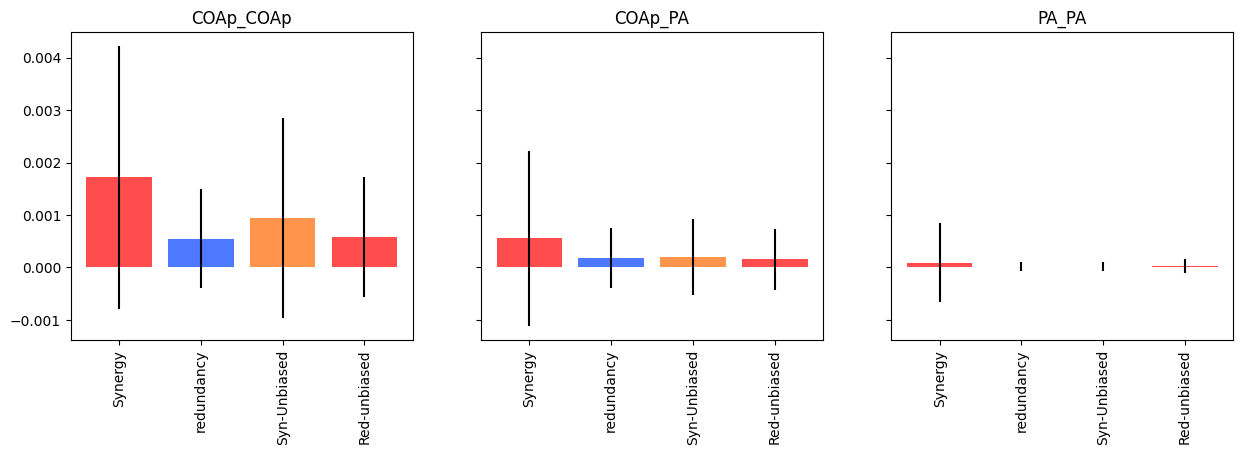

In [30]:
nrows, ncols = closest_factors(len(synergy.keys()))

fig, axes  = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4), sharey=True)


for idx, ax in enumerate(axes.flatten()):
    k = list(synergy.keys())[idx]
    mean_synergy = np.mean(synergy[k])
    mean_red = np.mean(redundancy[k])
    mean_redundancy_unbiased= np.mean(redundancy_unbiased[k])
    mean_synergy_unbiased= np.mean(synergy_unbiased[k])
    std_synergy = np.std(synergy[k])
    std_red = np.std(redundancy[k])
    std_redundancy_unbiased= np.std(redundancy_unbiased[k])
    std_synergy_unbiased= np.std(synergy_unbiased[k])
    ax.bar(np.arange(4),[mean_synergy, mean_red, mean_synergy_unbiased, mean_redundancy_unbiased],yerr=[std_synergy/2, std_red/2, std_synergy_unbiased/2, std_redundancy_unbiased/2], color=['#FF4D4D','#4D79FF','#FF944D'])
    ax.set_xticks([0,1,2,3],['Synergy','redundancy','Syn-Unbiased','Red-unbiased'],rotation=90)
    ax.set_title(k)

In [27]:
k = list(synergy.keys())[7]
print(k)

DG_VISpm


<Axes: ylabel='Count'>

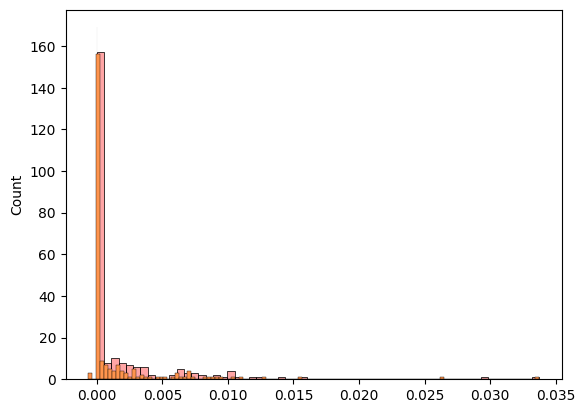

In [28]:

sns.histplot(synergy[k],  alpha=0.5, label='Synergy',color='#FF4D4D')
sns.histplot(redundancy[k],  alpha=1, label='Redundant',color='#4D79FF')
sns.histplot(coninfo[k],  alpha=1, label='Co-information',color='#FF944D')

In [10]:
from glob import glob

In [11]:
files = glob(f'{location}\subsampled\\*')

In [12]:
with open(files[9],'rb') as f:
    x = pkl.load(f)

In [16]:
files

['D:\\personal\\phD\\code\\information-decomposition\\ibl-partial-info-decomp\\data\\processed\\subsampled\\b52182e7-39f6-4914-9717-136db589706e_subsampled_biivariate_agr_dis_all.pkl',
 'D:\\personal\\phD\\code\\information-decomposition\\ibl-partial-info-decomp\\data\\processed\\subsampled\\b52182e7-39f6-4914-9717-136db589706e_subsampled_biivariate_agr_dis_neuron.pkl',
 'D:\\personal\\phD\\code\\information-decomposition\\ibl-partial-info-decomp\\data\\processed\\subsampled\\b52182e7-39f6-4914-9717-136db589706e_subsampled_biivariate_agr__.pkl',
 'D:\\personal\\phD\\code\\information-decomposition\\ibl-partial-info-decomp\\data\\processed\\subsampled\\b52182e7-39f6-4914-9717-136db589706e_subsampled_biivariate__dis_all.pkl',
 'D:\\personal\\phD\\code\\information-decomposition\\ibl-partial-info-decomp\\data\\processed\\subsampled\\b52182e7-39f6-4914-9717-136db589706e_subsampled_biivariate__dis_neuron.pkl',
 'D:\\personal\\phD\\code\\information-decomposition\\ibl-partial-info-decomp\\da

In [92]:
y = x.transpose(0,3,2,1) # for trivariate it is repetations x 1 x regions x values
# for bivariate it is repetations, regions, unique, mi

In [59]:
valx1 = x[0,0,:,:].reshape(-1,)
valx2 = x[0,1,:,:].reshape(-1,)
valx3 = x[0,2,:,:].reshape(-1,)

In [93]:

means = np.mean(y, axis=(0,1,))
stds = np.std(y, axis=(0,1,))
    

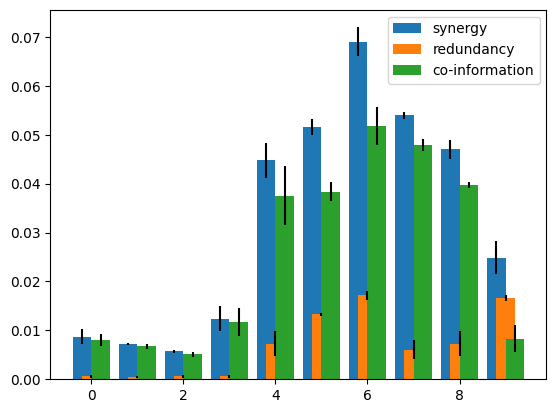

In [78]:
plt.bar(x=np.arange(10)-0.2, height=means[:,0], yerr=stds[:,0]/2, width=0.4,label='synergy')
plt.bar(x=np.arange(10), height=means[:,1], yerr=stds[:,1]/2, width=0.4,label='redundancy')
plt.bar(x=np.arange(10)+0.2, height=means[:,2], yerr=stds[:,2]/2, width=0.4, label='co-information')
plt.legend()

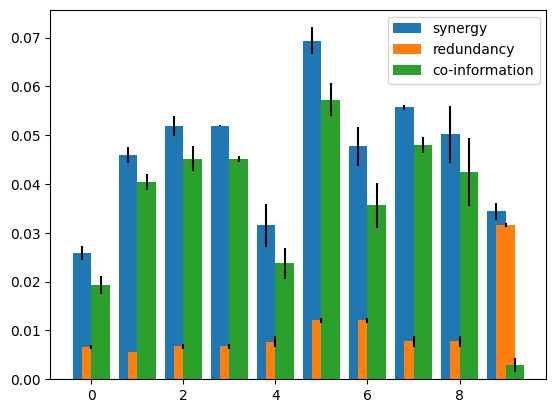

In [83]:
plt.bar(x=np.arange(10)-0.2, height=means[:,0], yerr=stds[:,0]/2, width=0.4,label='synergy')
plt.bar(x=np.arange(10), height=means[:,1], yerr=stds[:,1]/2, width=0.4,label='redundancy')
plt.bar(x=np.arange(10)+0.2, height=means[:,2], yerr=stds[:,2]/2, width=0.4, label='co-information')
plt.legend()

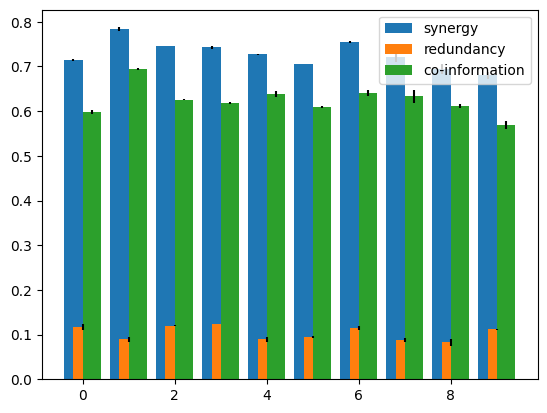

In [94]:
plt.bar(x=np.arange(10)-0.2, height=means[:,0], yerr=stds[:,0]/2, width=0.4,label='synergy')
plt.bar(x=np.arange(10), height=means[:,1], yerr=stds[:,1]/2, width=0.4,label='redundancy')
plt.bar(x=np.arange(10)+0.2, height=means[:,2], yerr=stds[:,2]/2, width=0.4, label='co-information')
plt.legend()

In [110]:

means = np.mean(x, axis=(0))
stds = np.std(x, axis=(0))

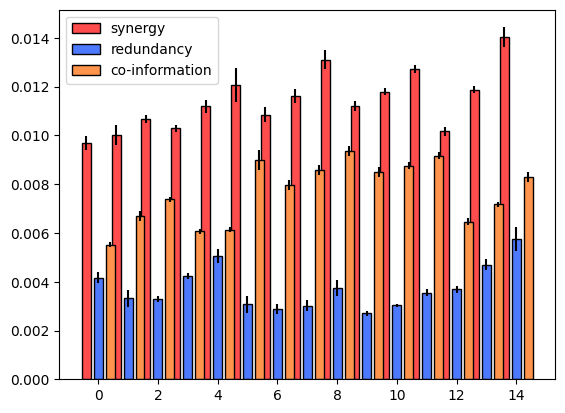

In [138]:
plt.bar(x=np.arange(len(means))-0.4, height=means[:,0], yerr=stds[:,0]/2, width=0.3,label='synergy',color='#FF4D4D',edgecolor='k')
plt.bar(x=np.arange(len(means)), height=means[:,1], yerr=stds[:,1]/2, width=0.3,label='redundancy',color='#4D79FF',edgecolor='k')
plt.bar(x=np.arange(len(means))+0.4, height=means[:,2], yerr=stds[:,2]/2, width=0.3, label='co-information',color='#FF944D',edgecolor='k')
plt.legend()

In [ ]:
# just generate plots

